# Identification des utilisateurs de Copilote

**MOD 7.2 (Introduction à la sciences des données)**, BE séances 1, 2, 3

**Enseignants :** Julien Velcin (CM, BE), Antoine Becquet (BE)

Le projet qu'on vous demande de réaliser concerne le traitement de **traces d'utilisation** du logiciel Copilote. Ce logiciel édité par la société Infologic, concerne le secteur de l'agro-alimentaire et est utilisé par de nombreux acteurs industriels.

L'étude de ces traces est très important pour l'entreprise. Elle permet entre autre d'améliorer son offre auprès de ses clients. Le projet vous propose de travailler sur des **modèles d'analyse automatique** de ces traces.

## Résolution du problème

Nous vous proposons de suivre les étapes suivantes dans le traitement de cette problématique :

- Prendre connaissance du problème et des données à votre disposition
- Chargement des données brutes en mémoire
- Première analyse de ces données
- Construction de caractéristiques adaptées
- Statistiques simples sur les variables construites
- Développement d'une solution de classification automatique
- Evaluation de votre solution
- Discussion au sujet de vos résultats


## Prendre connaissance du problème et des données à votre disposition

Pour commencer, allez lire la description plus détaillée du problème qui vous est donnée sur la page du challenge mis en place cette année (cf. lien fourni dans l'autre notebook).

Les données sont présentées plus en détail et téléchargeables via l'onglet "data".

L'objectif consiste à comprendre à quoi correspondent chacune des lignes du tableau des données et commencer à vous poser des questions sur la manière d'utiliser ces données pour répondre au challenge. Pour le moment, vous pouvez utiliser un **simple éditeur** (comme Notepad++, Sublime Text...) pour aller voir le contenu des fichiers, les importer dans Excel (mais attention car le volume peut rendre les manipulations difficiles), ou passer déjà par Python si vous êtes suffisamment à l'aise.

## Chargement des données brutes en mémoire

La toute première étape dans le traitement des données avec Python est de les charger en mémoire pour pouvoir mieux les examiner. Plusieurs solutions s'offrent alors à vous, parmi lesquelles :

- utiliser la librairie Pandas et les méthodes qui permettent de charger directement les données dans des DataFrame comme *readcsv*,
- ouvrir le fichier texte en mode lecture (*open*) et parcourir les lignes grâce à la commande *readlines()*

Cette dernière approche semble plus robuste au regard de la régularité du fichier d'entrée. Identifiez le délimiteur qui permet de séparer les différentes actions de l'utilisateur et utilisez-le pour construire la liste des actions réalisées.

In [1]:
import pandas as pd

def read_ds(ds_name: str):
    with open(f'data/{ds_name}.csv') as f:
        max_actions = max(( len( str(c).split(",")) for c in f.readlines() ))
        f.seek(0)
        _names = ["util", "navigateur"] if "train" in ds_name else ["navigateur"]
        _names.extend(range(max_actions - len(_names)))
        return pd.read_csv(f, names=_names, dtype= str)

In [2]:
features_train = read_ds("train")
features_test = read_ds("test")
features_train.shape, features_test.shape

((3279, 14470), (324, 7726))

In [3]:
features_train.head()

,util,navigateur,0,1,2,3,4,5,6,7,...,14458,14459,14460,14461,14462,14463,14464,14465,14466,14467
0,nuh,Firefox,Création d'un écran(infologic.core.accueil.Acc...,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Création d'un écran(infologic.core.gui.control...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,muz,Google Chrome,Création d'un écran(infologic.core.gui.control...,Création d'un écran(infologic.core.gui.control...,t5,Sélection d’un onglet(infologic.orga.modules.O...,t10,Exécution d'un bouton,t15,Sélection d’un onglet,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,zrx,Microsoft Edge,Affichage d'une dialogue(infologic.core.gui.co...,Exécution d'un bouton,Chainage,Fermeture d'une dialogue,Affichage d'une dialogue(infologic.acti.module...,Clic sur une grille d'historique de recherche,Raccourci,Fermeture d'une dialogue,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pou,Firefox,Création d'un écran(infologic.core.gui.control...,t5,Exécution d'un bouton(MAINT),Affichage d'une dialogue,Fermeture d'une dialogue,Double-clic,Exécution d'un bouton,Lancement d'une stat(infologic.core.gui.contro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ald,Google Chrome,Affichage d'une dialogue(infologic.acti.module...,t5,Exécution d'un bouton,Fermeture d'une dialogue,t10,Entrée en saisie dans un formulaire,t10,Affichage d'une dialogue,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Première analyse de ces données

Les données contiennent l'utilisateur (e.g. la variable dépendante, uniquement pour l'ensemble d'apprentissage), le navigateur choisi par l'utilisateur, puis toutes les actions effectuées dans la session par l'utilisateur actuel. Un marqueur spécial « tXX » indique un intervalle de temps de 5 secondes.

In [4]:
features_train.loc[:,:20].head()

,util,navigateur,0,1,2,3,4,5,6,7,...,11,12,13,14,15,16,17,18,19,20
0,nuh,Firefox,Création d'un écran(infologic.core.accueil.Acc...,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Création d'un écran(infologic.core.gui.control...,...,Fermeture d'une dialogue,Double-clic,Exécution d'un bouton,Lancement d'une stat(infologic.core.gui.contro...,Affichage d'un toast,Lancement d'une stat(infologic.core.gui.contro...,t10,Affichage d'une dialogue(MAINT),Exécution d'un bouton,Fermeture d'une dialogue
1,muz,Google Chrome,Création d'un écran(infologic.core.gui.control...,Création d'un écran(infologic.core.gui.control...,t5,Sélection d’un onglet(infologic.orga.modules.O...,t10,Exécution d'un bouton,t15,Sélection d’un onglet,...,Sélection d’un onglet(MAJ),t25,Sélection d'un écran(infologic.orga.modules.OR...,Sélection d'un écran,Exécution d'un bouton,Chainage,t30,Saisie dans un champ(MAINT)<DEF_03/24>1,Saisie dans un champ1,Saisie dans un champ1
2,zrx,Microsoft Edge,Affichage d'une dialogue(infologic.core.gui.co...,Exécution d'un bouton,Chainage,Fermeture d'une dialogue,Affichage d'une dialogue(infologic.acti.module...,Clic sur une grille d'historique de recherche,Raccourci,Fermeture d'une dialogue,...,Raccourci,Exécution d'un bouton,Affichage d'une dialogue,t10,Clic sur une grille d'historique de recherche,Raccourci,Exécution d'un bouton,Affichage d'une dialogue,Fermeture d'une dialogue,Clic sur une grille d'historique de recherche
3,pou,Firefox,Création d'un écran(infologic.core.gui.control...,t5,Exécution d'un bouton(MAINT),Affichage d'une dialogue,Fermeture d'une dialogue,Double-clic,Exécution d'un bouton,Lancement d'une stat(infologic.core.gui.contro...,...,Sélection d'un flag,Filtrage / Tri,t15,Affichage d'une dialogue,Clic sur une grille d'historique de recherche,Affichage d'une dialogue,t20,Exécution d'un bouton,Fermeture d'une dialogue,Création d'un écran(infologic.acti.modules.AT_...
4,ald,Google Chrome,Affichage d'une dialogue(infologic.acti.module...,t5,Exécution d'un bouton,Fermeture d'une dialogue,t10,Entrée en saisie dans un formulaire,t10,Affichage d'une dialogue,...,Sélection d'un écran(infologic.crm.modules.CRM...,Exécution d'un bouton,Action de table,Affichage d'un toast,Affichage d'une dialogue,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Exécution d'un bouton,Entrée en saisie dans un formulaire


La première observation des données montre que nous avons un nombre considérable de colonnes (14470), mais la plupart d'entre elles semblent contenir des valeurs NaN, ce qui est logique puisque pandas étend les lignes comportant moins de colonnes afin qu'elles aient toutes le même nombre de colonnes, ajoutant ainsi des valeurs NaN aux champs manquants. Quelques utilisateurs ont gardé la même session pendant une très longue durée, alors que la plupart ont des sessions plus courtes ou de durée moyenne. Ainsi, les quelques sessions longues ont entraîné l'extension de toutes les autres à leur durée. C'est de là que proviennent toutes ces valeurs NaN.

In [5]:
# TODO: Inspecter les valeurs distinctes des navigateurs

Quelques fonctions "utilitaires" qui pourraient vous être utiles (ou pas) :

In [6]:
import warnings
from IPython.display import display, Markdown

# décorateurs utilitaires pour supprimer les avertissements de la sortie et imprimer un cadre de données dans un tableau Markdown.
def ignore_warnings(f):
    def _f(*args, **kwargs):
        warnings.filterwarnings('ignore')
        v = f(*args, **kwargs)
        warnings.filterwarnings('default')
        return v
    return _f

# affiche un DataFrame Pandas sous forme de tableau Markdown dans un notebook Jupyter.
def markdown_table(headNtail=False, use_index=True, title=None, precision=2):
    def _get_value(val): return str(round(val, precision) if isinstance(val, float) else val)
    def _format_row(row): 
        row_str = ""
        if use_index: row_str += f"|{str(row.name)}"
        for value in row.values: row_str += f"| {_get_value(value)}"
        return row_str + "|"
    def _get_str(df):
        return "\n".join(df.apply(_format_row, axis=1))
    def _deco(f):
        def _f(*args, **kwargs):
            df = f(*args, **kwargs)
            _str = f"#### {title}\n" if title else ""
            header = ([str(df.index.name)] if use_index else []) + df.columns.astype(str).to_list() 
            _str += f"|{'|'.join(header)}|" + f"\n|{'--|'*len(header)}\n" if header else None
            if headNtail:
                _str += _get_str(df.head())
                _str += "\n|...|...|\n"
                _str += _get_str(df.tail())
            else:
                _str += _get_str(df)
            display(Markdown(_str))
        return _f
    return _deco

# fonction utilitaire permettant d'obtenir une grille graphique à partir d'un nombre arbitraire de lignes/colonnes ou de données.
def get_grid(n, n_row=None, n_col=None, titles=None, figsize=(10, 8), wspace=.5, hspace=.5, **kwargs):
    if n_row: n_col= n_col or math.floor(n/n_row)
    elif n_col: n_row= n_row or math.ceil(n/n_col)
    else:
        n_row = math.ceil(math.sqrt(n))
        n_col = math.floor(n/n_row)
    fig, axs = plt.subplots(n_row, n_col, figsize=figsize, **kwargs)
    plt.subplots_adjust(hspace=hspace, wspace=wspace)
    if titles is not None:
        for ax, title in zip(axs.flat, titles): ax.set_title(title)
    return fig, axs

Maintenant que nous avons un premier aperçu de nos données, approfondissons un peu et examinons quelques statistiques à leur sujet.

In [ ]:
@markdown_table(title="Navigateur par utilisateur", headNtail=True)
def browsers_per_player(df):
    # Afficher ici pour chaque utilisateur (en ligne) le nombre de fois qu'il a utilisé chaque navigateur (en colonne)

# TODO: inspecter d'autre statistiques du jeu de données (la variable dépendante Y sera inspecté dans la prochaine cellule)

// Votre analyse ici

In [ ]:
@markdown_table(headNtail=True, title="Stats: Y distribution")
def get_Y_stats(df):
    # Inspecter la distribution de la variable dépendante ici (Y)

// Votre analyse ici

## Construction de caractéristiques

### Traitements préliminaires

En fonction du modèle choisi, différentes étapes de pré-traitement peuvent être nécessaire. Voir https://scikit-learn.org/stable/supervised_learning.html pour des exemples de modèles dans le cas supervisé (notre cas). Quelques exemples : 
- SVMs
- Régression logistiques
- Arbres de décision
- Modèle ensembliste (Random Forest, XGBoost, etc.)
- Réseaux de neurones 

Il faut commencer par se demander s'il y a des valeurs aberrantes (*outliers*) et, le cas échéant, appliquer le traitement approprié (pour le moment vous pouvez à priori les supprimer).

In [ ]:
# TODO: inspecter s'il y a des valeurs aberrantes, et les enlever le cas échéant

### Variable de classe
Notre variable dépendante est une chaîne de caractères (str). Nous pouvons la convertir en codes catégoriels (numériques) à l'aide de la fonction pd.Categorical.

In [ ]:
features_train["util"] = pd.Categorical(features_train["util"])

pd.Categorical ne modifie pas directement l'ID utilisateur en un nombre, mais lui ajoute un attribut cat.codes. Nous pouvons créer une petite fonction pour convertir la variable de classe d'une chaîne de caractères en son ID de catégorie :

In [ ]:
def to_categories(df, col="util"):
    df[[col]] = df[[col]].apply(lambda x: x.cat.codes)

### Obtention des caractéristiques...

Nous allons maintenant créer des caractéristiques à partir de l'ensemble de données. Pour cela, il va falloir comprendre leur format, les parser et voir comment les agréger. On peut commencer par inspecter toutes les actions différentes, indépendemment des informations sur l'écran ou la fiche travaillée.

In [ ]:
def filter_action(value: str):
    for delim in [ "(", "<", "$", "1"]:
        if delim in value and (low_ind := value.index(delim)):
            value = value[:low_ind]
    return value

uniques = features_train.iloc[:,2:].stack().unique()
filtered_uniques = list(set([filter_action(un) for un in uniques if not un.startswith("t")]))
len(filtered_uniques), filtered_uniques

In [ ]:
#TODO Définir des features sur les données brutes et les placer dans un nouveau dataframe

Ensuite, on peut employer des fonctions plus complexes pour extraire l'écran le plus utilisé, la configuration d'écran la plus utilisé et la chaîne (catégorie) de la fiche la plus utilisé. Pour vous aider, voici les expressions régulières (*regex*) qui permettent d'extraire de telles informations. N'hésitez pas à extraire d'autres informations si cela vous parait pertinent.

In [ ]:
import re
from collections import Counter

pattern_ecran = re.compile(r"\((.*?)\)")
pattern_conf_ecran = re.compile(r"<(.*?)>")
pattern_chaine = re.compile(r"\$(.*?)\$")


### Traitement des chaînes de caractère
La colonne navigateur ne peut prendre que quatre valeurs ; pour la convertir en nombre, on a deux choix : 
- la convertir en variable catégorielle comme nous l'avons fait avec notre variable dépendante
- la convertir en One-Hot Encoding (OHE), un pour chaque navigateur. Pandas propose également une fonction pour cela : get_dummies

En fonction du modèle, l'un ou l'autre peut être plus pertinent (par exemple, pour un arbre de décision ?).

In [ ]:
#TODO : traiter les chaînes de caractères

## Statistiques simples sur les variables

### Inspection des caractéristiques

Commencez par inspecter les caractéristiques que vous avez construites, et afficher des graphiques en les interprétant. Vous pouvez utiliser la librairie Matplotlib à cette fin.

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True, figsize=(20,6))
# TODO: afficher des graphiques de trois features différentes sur les trois axes donnés

// Votre analyse ici

### Inspection de la corrélation d'une caractéristique pour une classe particulière
Comme il peut être difficile d'inspecter les données lorsque nous avons un tel nombre de classes possibles, nous pouvons commencer par tracer des graphiques de corrélation pour une ou quelques cibles particulières, choisies arbitrairement.


In [ ]:
def plot_categories(categories, type_="box", feature="actions_means"):
    fig, axs = get_grid(len(categories), n_row=1, figsize=(16, 4))
    # TODO : afficher les graphiques des catégories passées en paramètre

In [ ]:
categories = [0, 15, 152, 199]
plot_categories(categories)

Un boxplot est très utile pour estimer la distribution d'une caractéristique au sein d'une catégorie (cf. cours), mais d'autres visualisations peuvent servir comme les violin plots, cf. : https://www.data-to-viz.com



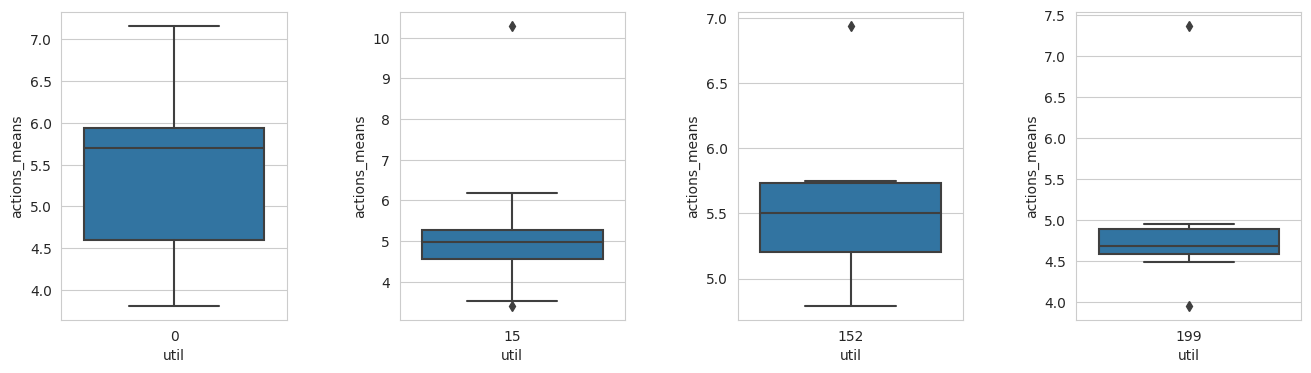

// à compléter

## Développement d'une solution de classification automatique

Une fois que vous avez exploré les données et mieux compris comment résoudre la tâche qui vous est confiée, c'est le moment de commencer à développer votre solution de classification automatique supervisée.

La première opération consiste à séparer votre jeu de données en deux sous-ensembles : un jeu d'entraînement (**training set**) et un jeu de validation (**validation set**). Le jeu de validation vous aidera dans la sélection du meilleur modèle. Suivant les algorithmes employés, et leur coût computationnel, vous pourriez aussi avoir recours à la validation croisée à K-folds (*K-fold cross validation*).

Il s'agit ensuite de tester plusieurs algorithmes classiques et de faire varier ses hyper-paramètres, tel que :

- Régression logistique
- Machines à vecteurs supports (SVM) : différents types de noyau (linéaire, polynomial à différents degrés)
- Arbres de décisions simples
- Ensembles d'arbres (Random Forest, XGBoost) : nombre d'arbres
- Réseaux de neurones artificiels (simple MLP) : nombre de couches, nombre de neurones par couche

Vous pouvez également tester les méthodes de régularisation afin d'obtenir des modèles parcimonieux.

Pour cela, vous privilégierez l'usage de la librairie *scikit-learn*.

## Evaluation de votre solution

Les algorithmes déployés dans la section précédente permettent de réaliser des prédictions sur des données qui n'ont pas été vus durant l'entraînement. Dans le cadre de cette compétition, vous utiliserez pour ça un ensemble de validation.

Il s'agit à présent de définir convenablement et d'utiliser les métriques les plus appropriées à votre tâche. On vous conseille à minima d'employer la **réussite simple** en classification (*accuracy*) et la **F-Mesure** (ou F1-score) mais vous êtes aussi encouragés à utiliser d'autres manière d'évaluer l'efficacité d'un modèle.

// à compléter

## Discussion au sujet de vos résultats

Il faut discuter de vos résultats, si possible en prenant en compte tous les critères que vous jugerez utiles (cf. mesures discutées dans la partie précédente).

### Interprétabilité avec les modèles de ML
Nous prenons pour example les modèles de forêt aléatoire, mais ces questions peuvent aussi être applicables dans le cas d'autres modèles.

La forêt aléatoire devrait nous permettre de répondre à cinq questions :

* Quel est notre degré de confiance dans nos prédictions à partir d'une ligne de données particulière ?
* Pour prédire à partir d'une ligne de données particulière, quels ont été les facteurs les plus importants et comment ont-ils influencé cette prédiction ?
* Quelles colonnes sont les prédicteurs les plus forts ?
* Quelles colonnes sont effectivement redondantes les unes par rapport aux autres, aux fins de la prédiction ?
* Comment les prédictions varient-elles lorsque nous modifions ces colonnes ?

Extrait de *Deep Learning for Coders with Fastai and PyTorch: AI Applications Without a PhD*  par Jeremy Howard, Sylvain Gugger

Essayez d'y répondre !
Pour cela, allez sur la page scikit-learn de votre algorithme (voire sur des forums), et inspecter ses méthodes / attributs.

## Evaluation sur l'ensemble de données de test

Il s'agit enfin d'utiliser votre modèle sur l'ensemble de données de test fourni.

In [ ]:
#TODO: preprocess test dataset, compute features values and post-process it (handle string, etc.)
test_processed_df = # TODO

In [ ]:
preds_test =  votre_modele.predict(test_processed_df)
preds_test

## Soumission à la compétition Kaggle

Il faut bien mettre en forme le fichier que vous pourrez utiliser pour soumettre sur le site de la compétitiokn.

In [ ]:
preds_test = pd.Categorical.from_codes(preds_test, features_train["util"].cat.categories)
df_subm = pd.DataFrame(preds_test)
df_subm = df_subm.rename_axis('RowId')
df_subm.rename(columns={0: 'prediction'}, inplace=True)
df_subm.index = df_subm.index + 1
df_subm

In [ ]:
df_subm.to_csv('submission.csv')